In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

In [2]:
# Load the CSV file into a DataFrame
df = pd.read_csv(r'C:\Users\oluwa\Desktop\HNG INTERNSHIP\STAGE 2\LAGOS_crosschecked.csv')

# Display the first 5 rows of the DataFrame
df.head(5)

,State,LGA,Ward,PU-Code,PU-Name,Accredited_Voters,Registered_Voters,Results_Found,Transcription_Count,Result_Sheet_Stamped,Result_Sheet_Corrected,Result_Sheet_Invalid,Result_Sheet_Unclear,Result_Sheet_Unsigned,APC,LP,PDP,NNPP,Results_File
0,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-001,"ST. JOSEPH SECONDARY SCHOOL, MANGORO",120,744,True,-1,False,True,False,False,UNKNOWN,0,0,0,0,https://inec-cvr-cache.s3.eu-west-1.amazonaws....
1,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-002,"15, SHOMIDE STREET",111,716,True,-1,False,False,False,False,UNKNOWN,0,0,0,0,https://inec-cvr-cache.s3.eu-west-1.amazonaws....
2,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-004,"8, SEBIOTIMO STREET",108,843,True,-1,False,True,False,False,UNKNOWN,31,57,11,0,https://inec-cvr-cache.s3.eu-west-1.amazonaws....
3,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-005,"6, SEBIOTIMO STREET",114,731,True,-1,False,True,False,False,UNKNOWN,28,66,5,1,https://inec-cvr-cache.s3.eu-west-1.amazonaws....
4,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-006,WITHIN OLABI SQUARE,80,539,True,-1,False,False,False,False,UNKNOWN,24,28,16,1,https://inec-cvr-cache.s3.eu-west-1.amazonaws....


In [3]:
# Display information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11911 entries, 0 to 11910
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   State                   11911 non-null  object
 1   LGA                     11911 non-null  object
 2   Ward                    11911 non-null  object
 3   PU-Code                 11911 non-null  object
 4   PU-Name                 11911 non-null  object
 5   Accredited_Voters       11911 non-null  int64 
 6   Registered_Voters       11911 non-null  int64 
 7   Results_Found           11911 non-null  bool  
 8   Transcription_Count     11911 non-null  int64 
 9   Result_Sheet_Stamped    11911 non-null  bool  
 10  Result_Sheet_Corrected  11911 non-null  bool  
 11  Result_Sheet_Invalid    11911 non-null  bool  
 12  Result_Sheet_Unclear    11911 non-null  bool  
 13  Result_Sheet_Unsigned   11911 non-null  object
 14  APC                     11911 non-null  int64 
 15  LP

# DATA PREPARATION

In [4]:
# importing the geopy library and also time library
import geopy
from geopy.geocoders import Nominatim
import time

# Create a new column named Full_Address by combining the strings from PU-Name, Ward, LGA, and State columns
df['Full_Address'] =  df['LGA'] + ', ' + df['State'] + ', Nigeria'


In [5]:
# Using Nominatim to get the location
geolocator = Nominatim(user_agent="geoapi_immanuel_stage2_project")

# Creating a function to get latitude and longitude
def get_location(address):
    try:
        location = geolocator.geocode(address)
        if location is not None:
            return (location.latitude, location.longitude)
        else:
            return (None, None)
    except Exception as e:
        return (None, None)
    finally:
        time.sleep(1) 


In [6]:
# Getting unique addresses
unique_addresses = df['Full_Address'].unique()
lga_coordinates = {}

for address in unique_addresses:
    # Getting the location and storing in dictionary
    lat, lon = get_location(address)
    lga_coordinates[address] = (lat, lon)

In [7]:
# Mapping the Coordinates back to main df
df['Latitude'] = df['Full_Address'].map(lambda x: lga_coordinates.get(x, (None, None))[0])
df['Longitude'] = df['Full_Address'].map(lambda x: lga_coordinates.get(x, (None, None))[1])

In [8]:
# Checking for Missing Data
missing_lat = df['Latitude'].isna().sum()
print(f"Number of missing Latitude values: {missing_lat}")

missing_lon = df['Longitude'].isna().sum()
print(f"Number of missing Longitude values: {missing_lon}")

Number of missing Latitude values: 0
Number of missing Longitude values: 0


In [9]:
# Displaying the Result
df[['LGA', 'Full_Address', 'Latitude', 'Longitude']].head()

,LGA,Full_Address,Latitude,Longitude
0,AGEGE,"AGEGE, LAGOS, Nigeria",6.625252,3.31121
1,AGEGE,"AGEGE, LAGOS, Nigeria",6.625252,3.31121
2,AGEGE,"AGEGE, LAGOS, Nigeria",6.625252,3.31121
3,AGEGE,"AGEGE, LAGOS, Nigeria",6.625252,3.31121
4,AGEGE,"AGEGE, LAGOS, Nigeria",6.625252,3.31121


# Outlier Detection

In [10]:
# Calculating the voters turnout
df['voters_turnout'] = (df['Accredited_Voters'] / df['Registered_Voters'] * 100).round(2)

df[['Accredited_Voters', 'Registered_Voters', 'voters_turnout']].head(5)

,Accredited_Voters,Registered_Voters,voters_turnout
0,120,744,16.13
1,111,716,15.50
2,108,843,12.81
3,114,731,15.60
4,80,539,14.84


In [11]:
# Calculating total vote counts for each party
party_perf = {
    'APC': df['APC'].sum(),
    'LP': df['LP'].sum(),
    'PDP': df['PDP'].sum(),
    'NNPP': df['NNPP'].sum()
}

print("Total vote counts for each party:")
for party, votes in party_perf.items():
    print(f"{party}: {votes:,}")




Total vote counts for each party:
APC: 502,947
LP: 523,882
PDP: 69,700
NNPP: 7,114


In [12]:
# Calculating the perfomance percentage for each party
total_state_votes = df[['APC', 'LP', 'PDP', 'NNPP']].sum().sum()

df['Total_Votes_PU'] = df[['APC', 'LP', 'PDP', 'NNPP']].sum(axis=1)

# Calculating state vote percentage for LP since it had the highest votes
state_vote_lp = party_perf['LP']/total_state_votes * 100

# Calculating the PU vote percentage for LP
pu_vote_lp = df['LP'] / df['Total_Votes_PU'] * 100

In [13]:
# Calculating the Part Performance Index (PPI) for LP
df['PPI_LP'] = (pu_vote_lp / state_vote_lp) * 100

df[['LP', 'Total_Votes_PU', 'PPI_LP']].head(5)

,LP,Total_Votes_PU,PPI_LP
0,0,0,NaN
1,0,0,NaN
2,57,99,121.292737
3,66,100,139.039780
4,28,69,85.487787


In [14]:
# Handling missing values in PPI_LP column by filling with 100
df['PPI_LP'].fillna(100, inplace=True)

missing_values = df['PPI_LP'].isna().sum()
print(f"Number of missing values in PPI_LP column: {missing_values}")

Number of missing values in PPI_LP column: 0


In [15]:
# Checking the result of handling the missing value
df[['Total_Votes_PU', 'PPI_LP']].head(5)

,Total_Votes_PU,PPI_LP
0,0,100.000000
1,0,100.000000
2,99,121.292737
3,100,139.039780
4,69,85.487787


In [16]:
# Standardizing the selected columns
from sklearn.preprocessing import StandardScaler

x = df[['Latitude', 'Longitude', 'voters_turnout', 'PPI_LP']].copy()

scale = StandardScaler()
x_scaled = scale.fit_transform(x)

x = pd.DataFrame(x_scaled, columns=x.columns)

x.head(5)

,Latitude,Longitude,voters_turnout,PPI_LP
0,1.306519,-0.291674,-0.643241,0.086923
1,1.306519,-0.291674,-0.679196,0.086923
2,1.306519,-0.291674,-0.832718,0.504868
3,1.306519,-0.291674,-0.673489,0.853217
4,1.306519,-0.291674,-0.716863,-0.197931


In [17]:
# Applying Isolation Forest for Anomaly Detection
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=42)

iso_forest.fit(x)
df['Anomaly_Score'] = iso_forest.decision_function(x)

df.head(5)

,State,LGA,Ward,PU-Code,PU-Name,Accredited_Voters,Registered_Voters,Results_Found,Transcription_Count,Result_Sheet_Stamped,...,PDP,NNPP,Results_File,Full_Address,Latitude,Longitude,voters_turnout,Total_Votes_PU,PPI_LP,Anomaly_Score
0,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-001,"ST. JOSEPH SECONDARY SCHOOL, MANGORO",120,744,True,-1,False,...,0,0,https://inec-cvr-cache.s3.eu-west-1.amazonaws....,"AGEGE, LAGOS, Nigeria",6.625252,3.31121,16.13,0,100.000000,0.146443
1,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-002,"15, SHOMIDE STREET",111,716,True,-1,False,...,0,0,https://inec-cvr-cache.s3.eu-west-1.amazonaws....,"AGEGE, LAGOS, Nigeria",6.625252,3.31121,15.50,0,100.000000,0.144394
2,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-004,"8, SEBIOTIMO STREET",108,843,True,-1,False,...,11,0,https://inec-cvr-cache.s3.eu-west-1.amazonaws....,"AGEGE, LAGOS, Nigeria",6.625252,3.31121,12.81,99,121.292737,0.125893
3,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-005,"6, SEBIOTIMO STREET",114,731,True,-1,False,...,5,1,https://inec-cvr-cache.s3.eu-west-1.amazonaws....,"AGEGE, LAGOS, Nigeria",6.625252,3.31121,15.60,100,139.039780,0.124720
4,LAGOS,AGEGE,ISALE/IDIMANGORO,24-01-01-006,WITHIN OLABI SQUARE,80,539,True,-1,False,...,16,1,https://inec-cvr-cache.s3.eu-west-1.amazonaws....,"AGEGE, LAGOS, Nigeria",6.625252,3.31121,14.84,69,85.487787,0.142684


In [18]:
# Geospatial Deviation Analysis using Ball Tree
from sklearn.neighbors import BallTree

coord_rad = np.radians(df[['Latitude', 'Longitude']])

ball_tree = BallTree(coord_rad, metric='haversine')
radius = 1 / 6371

neighbor_indices = ball_tree.query_radius(coord_rad, r=radius)

for i in range(5):
    print(f"PU {i} neighbors' indices: {neighbor_indices[i]}")

PU 0 neighbors' indices: [    0     7    18    17    19    20     1    16     2     3     4     5
     6    15    14    13    12    11    10     9     8    21    22    23
    24    25    26    27    28    29    30    31    32    33    34    35
    36    37    38    39    40    41    45    46    47    48    49    50
    51    52    53    54    55    56    42    43    44    57    58    59
    61    62    60    63    64    65    66    67    68    69    70    71
    72    73    74    75    76    77    78    79    80    81    82    83
    84    85    86    87    89    90    91    92    93    94    95    96
    97    98    99   100   101    88   102   103   104   105   106   107
   108   109   110   111   112   113   114   115   116   117   118   119
   120   121   122   123   124   125   126   127   128   129   130   131
   136   141   142   143   145   137   144   135   134   133   132   146
   147   148   149   138   151   152   155   153   154   156   157   158
   140   139   150   159  

In [19]:
# Calculating Geospatial Deviation for the parties
target_parties = ['LP','APC','PDP','NNPP']
outliers = []

for i, neighbors in enumerate(neighbor_indices):
    current_pu_votes = df.loc[i, target_parties]
    neighbor_votes = df.loc[neighbors, target_parties]
    
    for party in target_parties:
        neighbor_votes_party = neighbor_votes.drop(i, errors='ignore')[party]
       
        pu_party_mean = neighbor_votes_party.mean()
        pu_party_std = neighbor_votes_party.std()
        
        current_vote = current_pu_votes[party]
        if pu_party_std == 0:
            deviation = 0
        else:
            deviation = abs(current_vote - pu_party_mean) / pu_party_std
            
        outliers.append((i, party, deviation))
        
        
deviation_scores_df = pd.DataFrame(outliers, columns=['PU_Index', 'Party', 'Deviation_Score'])

deviation_scores_df.head(10)

,PU_Index,Party,Deviation_Score
0,0,LP,1.322553
1,0,APC,1.922439
2,0,PDP,1.277520
3,0,NNPP,0.465962
4,1,LP,1.322553
5,1,APC,1.922439
6,1,PDP,1.277520
7,1,NNPP,0.465962
8,2,LP,2.527855
9,2,APC,0.471244


In [20]:
# Merging Deviation Scores with Main DataFrame and Identifying Top Outliers
df['Max_Geo_Deviation'] = deviation_scores_df.groupby('PU_Index')['Deviation_Score'].max()

df['Final_Outlier_Score'] = (df['Max_Geo_Deviation'] - df['Anomaly_Score'])

top_outliers = df.sort_values(by='Final_Outlier_Score', ascending=False).head(10)

report_columns = ['State', 'LGA', 'PU-Code', 'LP', 'APC', 'PDP', 'NNPP', 'Anomaly_Score', 'Max_Geo_Deviation', 'Final_Outlier_Score']

top_outliers[report_columns]

,State,LGA,PU-Code,LP,APC,PDP,NNPP,Anomaly_Score,Max_Geo_Deviation,Final_Outlier_Score
3039,LAGOS,IFAKO-IJAYE,24-10-04-010,380,240,312,255,0.108925,290.027491,289.918566
2179,LAGOS,BADAGRY,24-06-01-024,518,1,554,9,0.022705,38.527613,38.504908
8767,LAGOS,APAPA,24-05-02-013,36,1,44,50,0.107279,34.627392,34.520113
7223,LAGOS,SURULERE,24-20-05-019,4,67,1,49,0.123092,34.559179,34.436087
3311,LAGOS,IKEJA,24-11-03-001,1,68,5,27,0.088888,23.676279,23.587391
2736,LAGOS,ETI-OSA,24-08-05-021,539,0,124,0,0.030516,20.198669,20.168153
11123,LAGOS,OJO,24-17-05-061,0,30,1,43,0.020908,15.973552,15.952644
4071,LAGOS,KOSOFE,24-13-04-042,112,61,73,1,0.178297,16.093880,15.915582
6747,LAGOS,SOMOLU,24-19-08-016,1,64,4,17,0.117884,14.720539,14.602655
407,LAGOS,AGEGE,24-01-10-049,4,61,0,23,0.082687,13.325049,13.242362


# Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

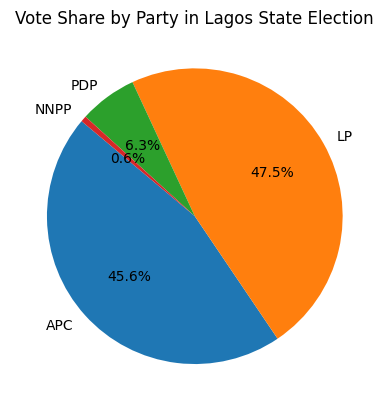

In [23]:
# Pie chart to visualize the vote share by parties
plt.pie(party_perf.values(),labels=party_perf.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Vote Share by Party in Lagos State Election')
plt.show()

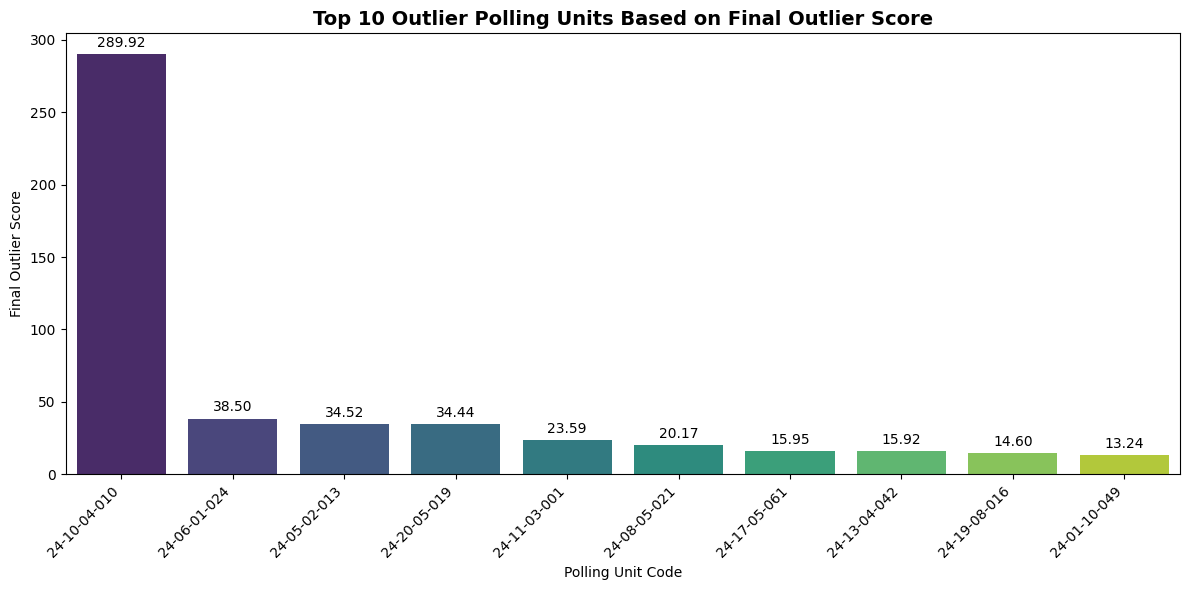

In [33]:
# Bar chart to visualize the top 10 outlier PUs based on Final Outlier Score
plt.figure(figsize=(12, 6))
ax =sns.barplot(x='PU-Code', y='Final_Outlier_Score', data=top_outliers.head(10), palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)
plt.title('Top 10 Outlier Polling Units Based on Final Outlier Score', fontsize=14, fontweight='bold')
plt.xlabel('Polling Unit Code')
plt.ylabel('Final Outlier Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

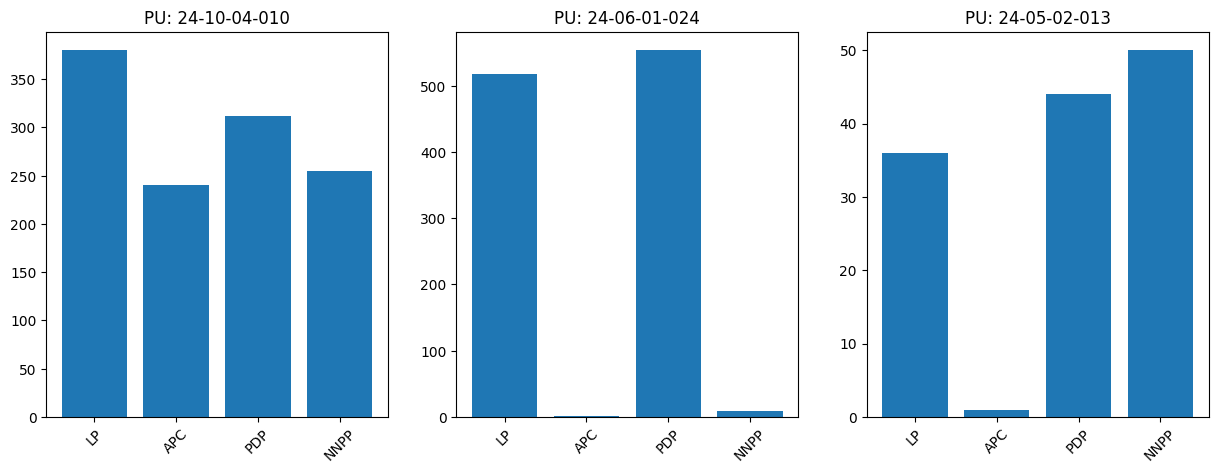

In [26]:
# Subplots for the top 3 outlier PUs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, pu_index in enumerate(top_outliers.index[:3]):
    votes = df.iloc[pu_index][['LP', 'APC', 'PDP', 'NNPP']]
    axes[i].bar(votes.index, votes.values)
    axes[i].set_title(f'PU: {df.iloc[pu_index]["PU-Code"]}')
    axes[i].tick_params(axis='x', rotation=45)

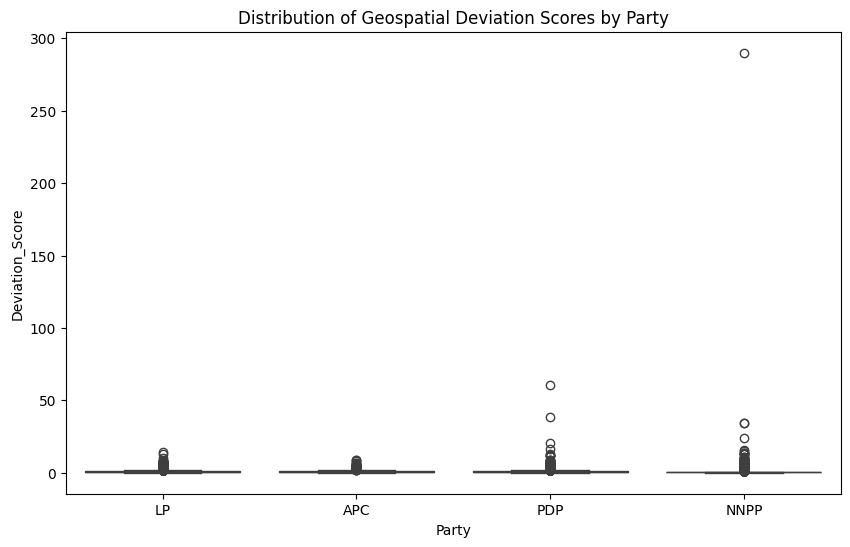

In [27]:
# Boxplot to show the deviation scores distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=deviation_scores_df, x='Party', y='Deviation_Score')
plt.title('Distribution of Geospatial Deviation Scores by Party')
plt.show()

In [34]:
# Saving the final DataFrame to a new CSV file
df.to_csv(r'cleaned_dataset_stage2.csv', index=False)

In [36]:
# CODE TO EXPORT THE SORTED OUTLIER LISTS (EXCEL)
parties = ['LP', 'APC', 'PDP', 'NNPP']
excel_file_name = 'sorted_party_outlier_scores.xlsx'

with pd.ExcelWriter(excel_file_name) as writer:
    df_merged = deviation_scores_df.merge(
        df[['State', 'LGA', 'PU-Code']], 
        left_on='PU_Index',   
        right_index=True,    
        how='left'
    )
    
    for party in parties:
        party_outliers = df_merged[df_merged['Party'] == party].sort_values(
            by='Deviation_Score', ascending=False
        )
        
        sheet_data = party_outliers[['State', 'LGA', 'PU-Code', 'Party', 'Deviation_Score']]
        sheet_data.to_excel(writer, sheet_name=f'{party}_Deviation_Scores', index=False)

print(f"Sorted Outlier Scores (Excel) exported as '{excel_file_name}' with sheets for LP, APC, PDP, and NNPP.")

Sorted Outlier Scores (Excel) exported as 'sorted_party_outlier_scores.xlsx' with sheets for LP, APC, PDP, and NNPP.
